In [1]:
from rdkit import Chem
from rdkit.Chem import Descriptors, AllChem, rdMolDescriptors, MACCSkeys
from rdkit.Chem.rdPartialCharges import ComputeGasteigerCharges
import numpy as np
import pandas as pd
import pickle
from rdkit.ML.Descriptors import MoleculeDescriptors
from rdkit.Chem import Descriptors
import matplotlib.pyplot as plt
from scipy import optimize

In [2]:
# plot settings
showPlots=1
useMagics=1
if useMagics:
    %matplotlib inline
    #%matplotlib notebook
    %load_ext autoreload
    %autoreload 2
    %reload_ext autoreload
    
font = {'weight' : 'normal',
        'size'   : 12}

plt.rc('font', **font)

In [3]:
descriptor_names = [desc[0] for desc in Descriptors._descList]
calculator = MoleculeDescriptors.MolecularDescriptorCalculator(descriptor_names)

def get_mol_from_substituents(subs_list):
    mol = Chem.RWMol()
    for sub in subs_list:
        smi = sub if sub else '[H]'
        frag = Chem.MolFromSmiles(smi)
        if frag is None:
            raise ValueError(f"Failed to parse SMILES: {smi}")
        mol.InsertMol(frag)
    Chem.SanitizeMol(mol)
    return mol

def extract_descriptors(mol):
    # Compute Gasteiger charges for charge-based stats
    ComputeGasteigerCharges(mol)
    
    # Get all standard RDKit descriptors
    values = calculator.CalcDescriptors(mol)
    descs = dict(zip(descriptor_names, values))

    # Add partial charge stats
    charges = [float(mol.GetAtomWithIdx(i).GetProp('_GasteigerCharge'))
               for i in range(mol.GetNumAtoms())
               if mol.GetAtomWithIdx(i).HasProp('_GasteigerCharge')]
    if charges:
        descs.update({
            'MaxPartialCharge': max(charges),
            'MinPartialCharge': min(charges),
            'MeanPartialCharge': np.mean(charges),
            'StdPartialCharge': np.std(charges)
        })
    else:
        descs.update({
            'MaxPartialCharge': np.nan,
            'MinPartialCharge': np.nan,
            'MeanPartialCharge': np.nan,
            'StdPartialCharge': np.nan
        })

    return descs

def featurize_cd_set(cd_list):
    features = []
    for subs in cd_list:
        mol = get_mol_from_substituents(subs)
        feat = extract_descriptors(mol)
        cd_type = len(subs)
        feat['CD type'] = cd_type
        unique_fg =list(set(subs))
        if len(unique_fg) > 1:
            grp = [item for item in unique_fg if item != '[OH]'][0]
            partial_fg_ratio = subs.count(grp)/len(subs)
        else:
            partial_fg_ratio = 1
        feat['Partial fg count'] = partial_fg_ratio

        features.append(feat)
    return pd.DataFrame(features)

In [4]:
# label_path = '/project2/andrewferguson/sachar/test/autodock-vina/chem_space_docking/functionalized-CD-PFAS-BO/data'
label_path = '.'
with open(f'{label_path}/chem_space.pkl', 'rb') as f:
    chem_space = pickle.load(f)

In [5]:
# my_list = [1, 2, 2, 3, 2, 4, 5]
# count_of_two = my_list.count(2)
# print(count_of_two)
# x.count('CI')
# x = prim_list[345]
# unique_fg =list(set(x))
# if len(unique_fg) > 1:
#     grp = [item for item in unique_fg if item != '[OH]'][0]
#     print(grp)
#     print(x.count(grp)/len(x))

In [6]:
# 

In [7]:
prim_list = [chem_space[k]['primary'] for k in chem_space.keys()]
df = featurize_cd_set(prim_list)
df
# featurize_cd_set(prim_list[:2])

[11:45:19] DEPRECATION WARNING: please use MorganGenerator
[11:45:19] DEPRECATION WARNING: please use MorganGenerator
[11:45:19] DEPRECATION WARNING: please use MorganGenerator
[11:45:19] DEPRECATION WARNING: please use MorganGenerator
[11:45:19] DEPRECATION WARNING: please use MorganGenerator
[11:45:19] DEPRECATION WARNING: please use MorganGenerator
[11:45:19] DEPRECATION WARNING: please use MorganGenerator
[11:45:19] DEPRECATION WARNING: please use MorganGenerator
[11:45:19] DEPRECATION WARNING: please use MorganGenerator
[11:45:19] DEPRECATION WARNING: please use MorganGenerator
[11:45:19] DEPRECATION WARNING: please use MorganGenerator
[11:45:19] DEPRECATION WARNING: please use MorganGenerator
[11:45:19] DEPRECATION WARNING: please use MorganGenerator
[11:45:19] DEPRECATION WARNING: please use MorganGenerator
[11:45:19] DEPRECATION WARNING: please use MorganGenerator
[11:45:19] DEPRECATION WARNING: please use MorganGenerator
[11:45:19] DEPRECATION WARNING: please use MorganGenerat

,MaxAbsEStateIndex,MaxEStateIndex,MinAbsEStateIndex,MinEStateIndex,qed,SPS,MolWt,HeavyAtomMolWt,ExactMolWt,NumValenceElectrons,...,fr_tetrazole,fr_thiazole,fr_thiocyan,fr_thiophene,fr_unbrch_alkane,fr_urea,MeanPartialCharge,StdPartialCharge,CD type,Partial fg count
0,0.000000,0.000000,0.000000,0.000000,0.346084,0.000000,559.328,559.328,552.428360,49,...,0,0,0,0,0,0,0.000000,0.000000,7,1.000
1,0.000000,0.000000,0.000000,0.000000,0.275014,0.000000,639.232,639.232,631.346697,56,...,0,0,0,0,0,0,0.000000,0.000000,8,1.000
2,3.104167,3.104167,0.270833,0.270833,0.212135,9.000000,1769.117,1762.061,1748.339854,182,...,0,0,0,0,0,0,-0.016732,0.081380,7,1.000
3,3.104167,3.104167,0.270833,0.270833,0.212135,9.000000,2021.848,2013.784,1998.102691,208,...,0,0,0,0,0,0,-0.016732,0.081380,8,1.000
4,5.452932,5.452932,1.163580,-1.898534,0.222949,14.400000,1996.484,1989.428,1972.528557,434,...,0,0,0,0,0,0,-0.006788,0.129000,7,1.000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1624,8.000000,8.000000,0.000000,0.000000,0.336713,3.600000,310.044,308.028,309.962899,116,...,0,0,0,0,0,0,-0.025456,0.270743,8,0.750
1625,8.000000,8.000000,0.000000,0.000000,0.336713,3.600000,310.044,308.028,309.962899,116,...,0,0,0,0,0,0,-0.025456,0.270743,8,0.750
1626,8.000000,8.000000,0.000000,0.000000,0.336713,3.600000,310.044,308.028,309.962899,116,...,0,0,0,0,0,0,-0.025456,0.270743,8,0.750
1627,8.000000,8.000000,0.000000,0.000000,0.336713,3.600000,310.044,308.028,309.962899,116,...,0,0,0,0,0,0,-0.025456,0.270743,8,0.750


In [8]:
# Calculate standard deviation for each column in df
std_df = df.std()

# Identify columns with low standard deviation (< 0.01)
low_std_cols = std_df[std_df.values < 0.01].index.values

# Remove low variance columns from df
df_nocorr = df.loc[:, [col for col in df.columns if col not in low_std_cols]]

df_nocorr

,MaxAbsEStateIndex,MaxEStateIndex,MinAbsEStateIndex,MinEStateIndex,qed,SPS,MolWt,HeavyAtomMolWt,ExactMolWt,NumValenceElectrons,...,fr_NH0,fr_NH2,fr_alkyl_halide,fr_ether,fr_halogen,fr_methoxy,MeanPartialCharge,StdPartialCharge,CD type,Partial fg count
0,0.000000,0.000000,0.000000,0.000000,0.346084,0.000000,559.328,559.328,552.428360,49,...,0,0,0,0,7,0,0.000000,0.000000,7,1.000
1,0.000000,0.000000,0.000000,0.000000,0.275014,0.000000,639.232,639.232,631.346697,56,...,0,0,0,0,8,0,0.000000,0.000000,8,1.000
2,3.104167,3.104167,0.270833,0.270833,0.212135,9.000000,1769.117,1762.061,1748.339854,182,...,0,0,21,0,21,0,-0.016732,0.081380,7,1.000
3,3.104167,3.104167,0.270833,0.270833,0.212135,9.000000,2021.848,2013.784,1998.102691,208,...,0,0,24,0,24,0,-0.016732,0.081380,8,1.000
4,5.452932,5.452932,1.163580,-1.898534,0.222949,14.400000,1996.484,1989.428,1972.528557,434,...,0,0,49,0,49,0,-0.006788,0.129000,7,1.000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1624,8.000000,8.000000,0.000000,0.000000,0.336713,3.600000,310.044,308.028,309.962899,116,...,6,0,0,0,0,0,-0.025456,0.270743,8,0.750
1625,8.000000,8.000000,0.000000,0.000000,0.336713,3.600000,310.044,308.028,309.962899,116,...,6,0,0,0,0,0,-0.025456,0.270743,8,0.750
1626,8.000000,8.000000,0.000000,0.000000,0.336713,3.600000,310.044,308.028,309.962899,116,...,6,0,0,0,0,0,-0.025456,0.270743,8,0.750
1627,8.000000,8.000000,0.000000,0.000000,0.336713,3.600000,310.044,308.028,309.962899,116,...,6,0,0,0,0,0,-0.025456,0.270743,8,0.750


In [9]:
threshold = 0.70
corr_mat = df_nocorr.corr(method="spearman")
to_keep = []
to_remove = []
bags = {}

while len(to_keep) + len(to_remove) != len(df_nocorr.columns):
    curr_to_remove = []
    curr_col = corr_mat.columns[0]
    curr_vals = corr_mat[curr_col][1:]
    for i, val in enumerate(curr_vals):
        if abs(val) >= threshold:
            curr_to_remove.append(corr_mat.columns[i+1])
    to_keep.append(curr_col)
    to_remove.extend(curr_to_remove)
    bags[curr_col] = curr_to_remove
    corr_mat = df_nocorr.drop(columns=to_keep+to_remove).corr(method="spearman")

df_selected = df_nocorr[to_keep]

In [10]:

X_fit = []
Y_fit_dG_md = []
Y_fit_ddG_md = []
df_numpy = df_selected.to_numpy()
for i, k in enumerate(chem_space.keys()):
    if chem_space[k]['ddG_md'] is not None:
        X_fit.append(df_numpy[i])
        Y_fit_dG_md.append(-chem_space[k]['dG_md'][0])
        Y_fit_ddG_md.append(-chem_space[k]['ddG_md'][0])

X_fit = np.asarray(X_fit)
Y_fit_dG_md = np.asarray(Y_fit_dG_md).reshape(-1, 1)
Y_fit_ddG_md = np.asarray(Y_fit_ddG_md).reshape(-1, 1)


/home/siddarthachar/miniconda3/envs/graphdot_env/lib/python3.8/site-packages/sklearn/linear_model/_coordinate_descent.py:628: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 2.536e+02, tolerance: 9.377e-01
  model = cd_fast.enet_coordinate_descent(
/home/siddarthachar/miniconda3/envs/graphdot_env/lib/python3.8/site-packages/sklearn/linear_model/_coordinate_descent.py:628: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 2.538e+02, tolerance: 9.377e-01
  model = cd_fast.enet_coordinate_descent(
/home/siddarthachar/miniconda3/envs/graphdot_env/lib/python3.8/site-packages/sklearn/linear_model/_coordinate_descent.py:628: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, c

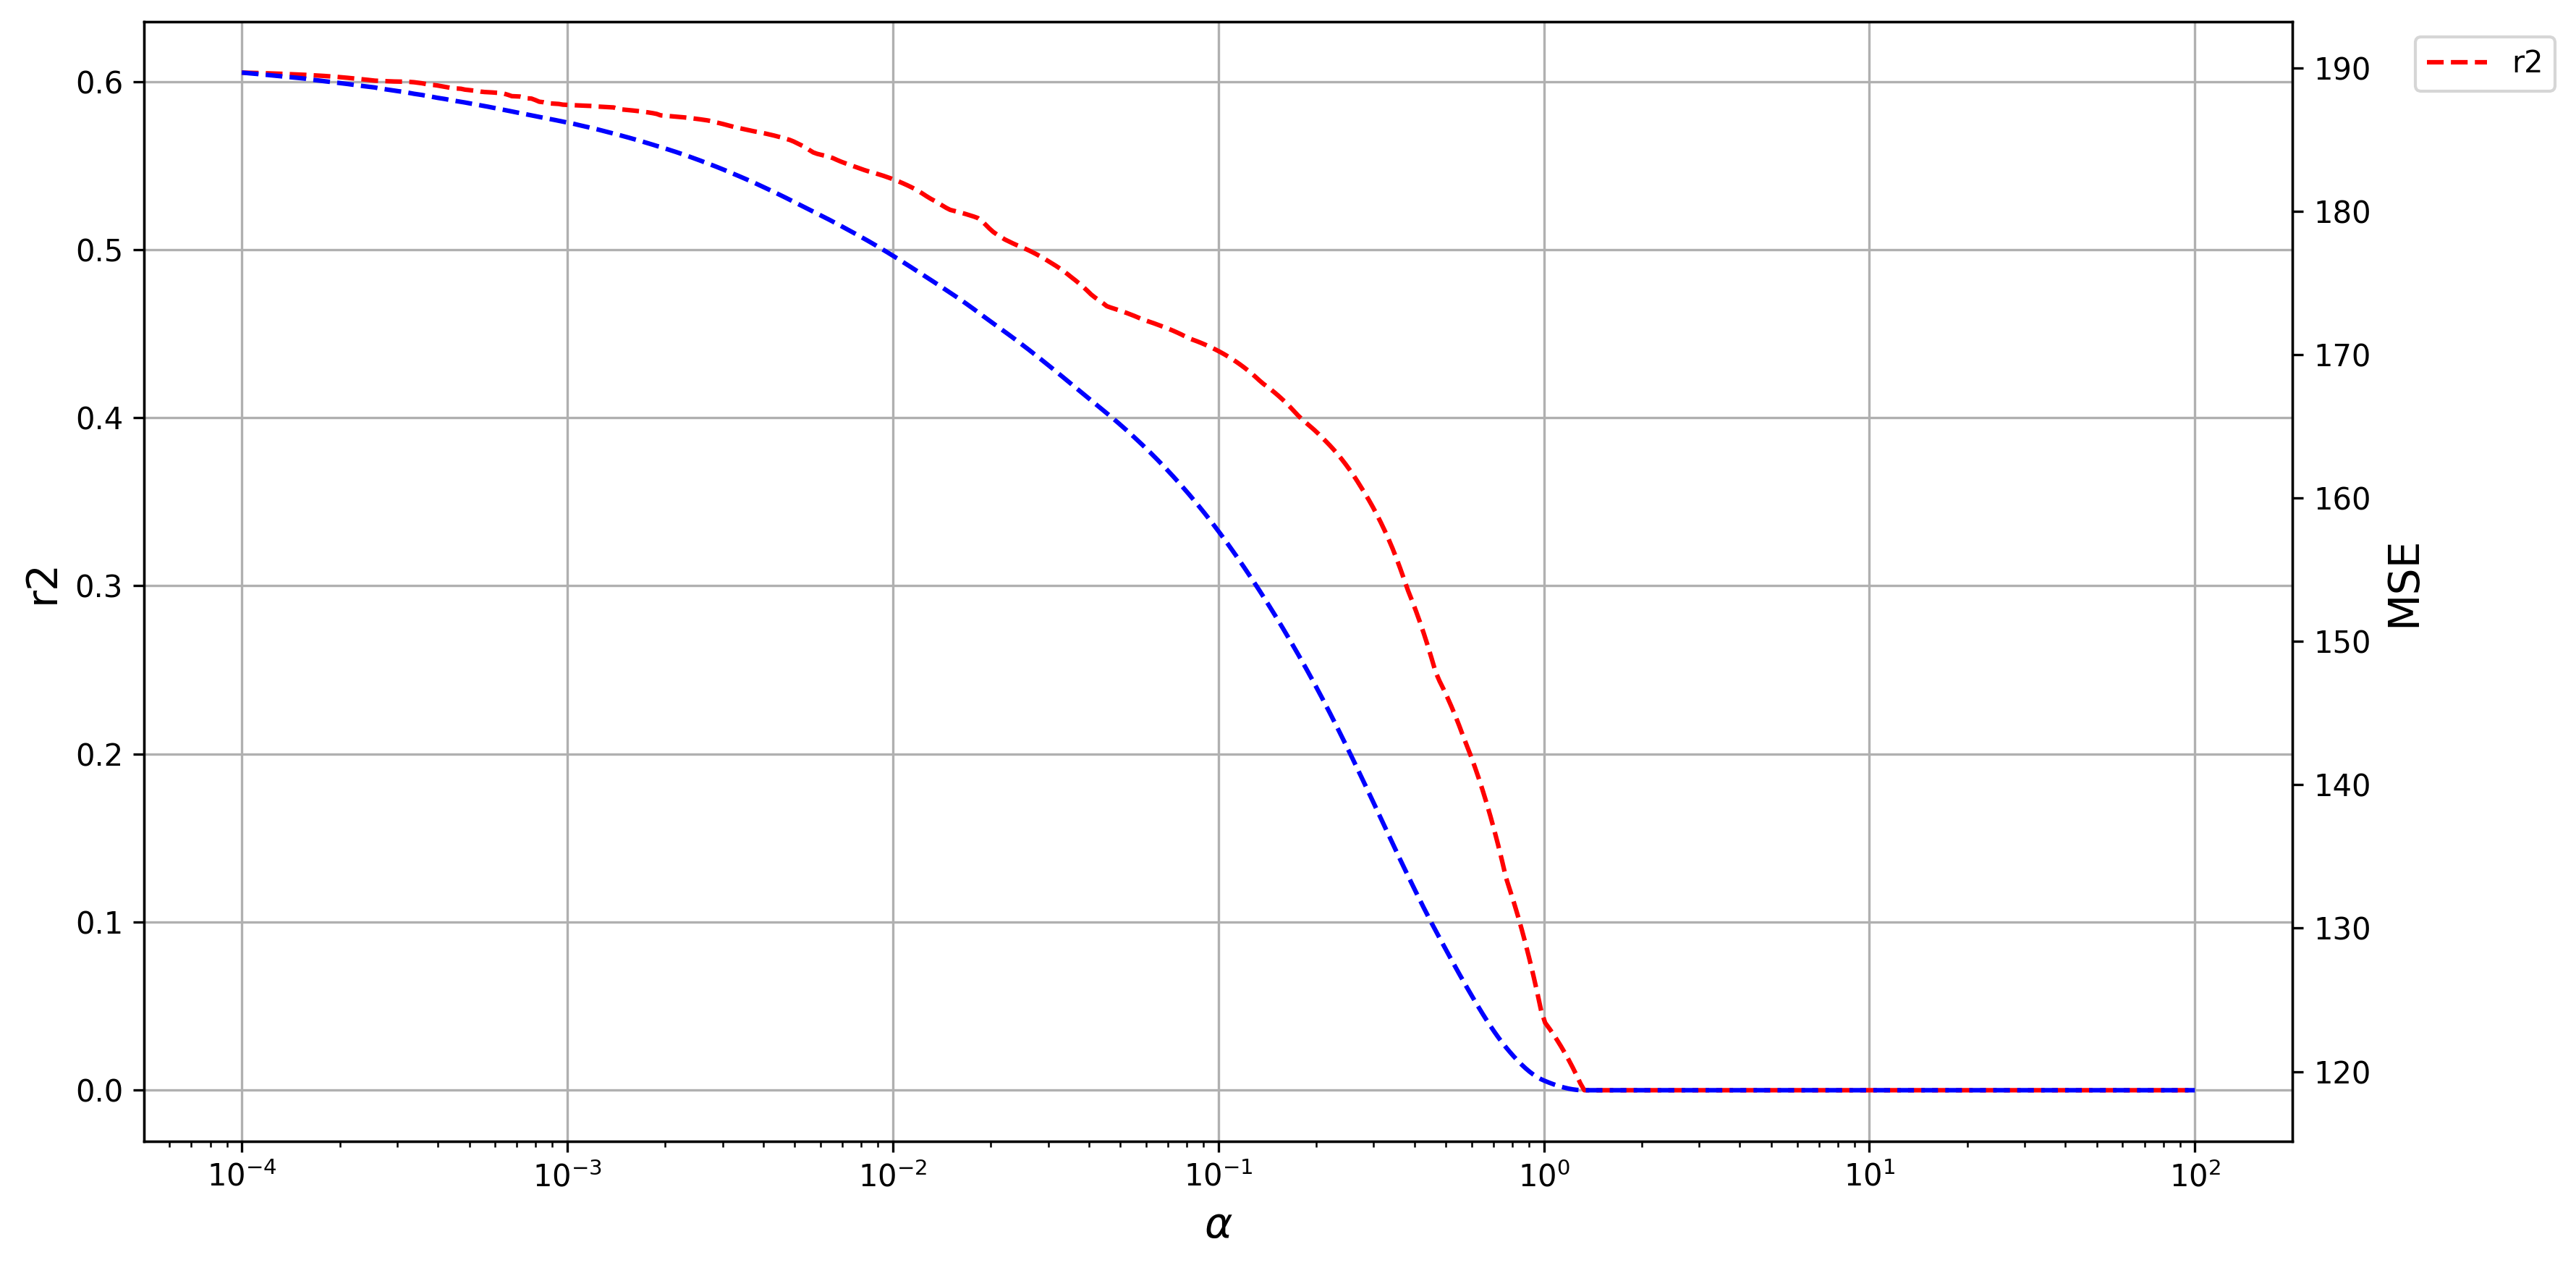

In [11]:
from sklearn.linear_model import Lasso
from sklearn.preprocessing import MinMaxScaler

# Define grid of lambda values (alphas in sklearn)
alphas = np.logspace(-4, 2, 500)
n_features = X_fit.shape[1]
y = Y_fit_dG_md

# Store coefficients for each alpha and each fold
r2_scores = np.zeros((len(alphas), ))
MSE = np.zeros((len(alphas), ))
models = []

scaler_all_vina = MinMaxScaler()
X_train = scaler_all_vina.fit_transform(X_fit)
for j, alpha in enumerate(alphas):
    model = Lasso(alpha=alpha, max_iter=100000)
    model.fit(X_train, y)
    r2_scores[j] = model.score(X_train, y)
    MSE[j] = ((model.predict(X_train)-y)**2).mean()
    models.append(model)

fig, ax = plt.subplots(figsize=(12, 6), dpi=300)
colors = plt.cm.tab20.colors

ax2 = ax.twinx()
ax.plot(alphas, r2_scores, "--r", label="r2")
ax2.plot(alphas, MSE, "--b", label="MSE")
ax.grid()
ax.set_xscale("log")
ax.set_xlabel(r"$\alpha$", fontsize=14)
ax.set_ylabel("r2", fontsize=14)
ax.legend(bbox_to_anchor=(1.05, 1), loc='upper left', fontsize='small', ncol=2)
ax.tick_params(axis="both", which='major', labelsize=10)
ax2.tick_params(axis="both", which='major', labelsize=10)
ax2.set_ylabel("MSE", fontsize=14)
fig.tight_layout()
plt.show()

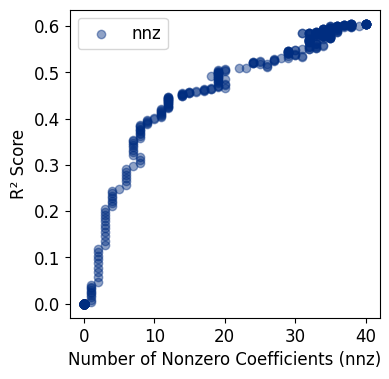

In [12]:
fig, ax = plt.subplots(1, 1, figsize=(4, 4), dpi=100)
# ax.set_xscale("log")

nnz = [len(model.coef_.nonzero()[0]) for model in models]
r2_clean = r2_scores

nnz = np.asarray(nnz)
r2_clean = np.asarray(r2_clean)

ax.scatter(nnz, r2_clean, color="#002D806F", label="nnz")
ax.set_xlabel("Number of Nonzero Coefficients (nnz)")
ax.set_ylabel("R² Score")
ax.legend()
plt.show()

In [13]:
alphas[np.where(nnz==7)]#, nnz_unique, r2_clean_unique, len(alphas)

array([0.28242413, 0.29035269, 0.29850382, 0.30688379, 0.31549901,
       0.32435608, 0.3334618 , 0.34282315, 0.38297139])

Fitted x0: 7.88
Corresponding alpha ≈ 0.2141


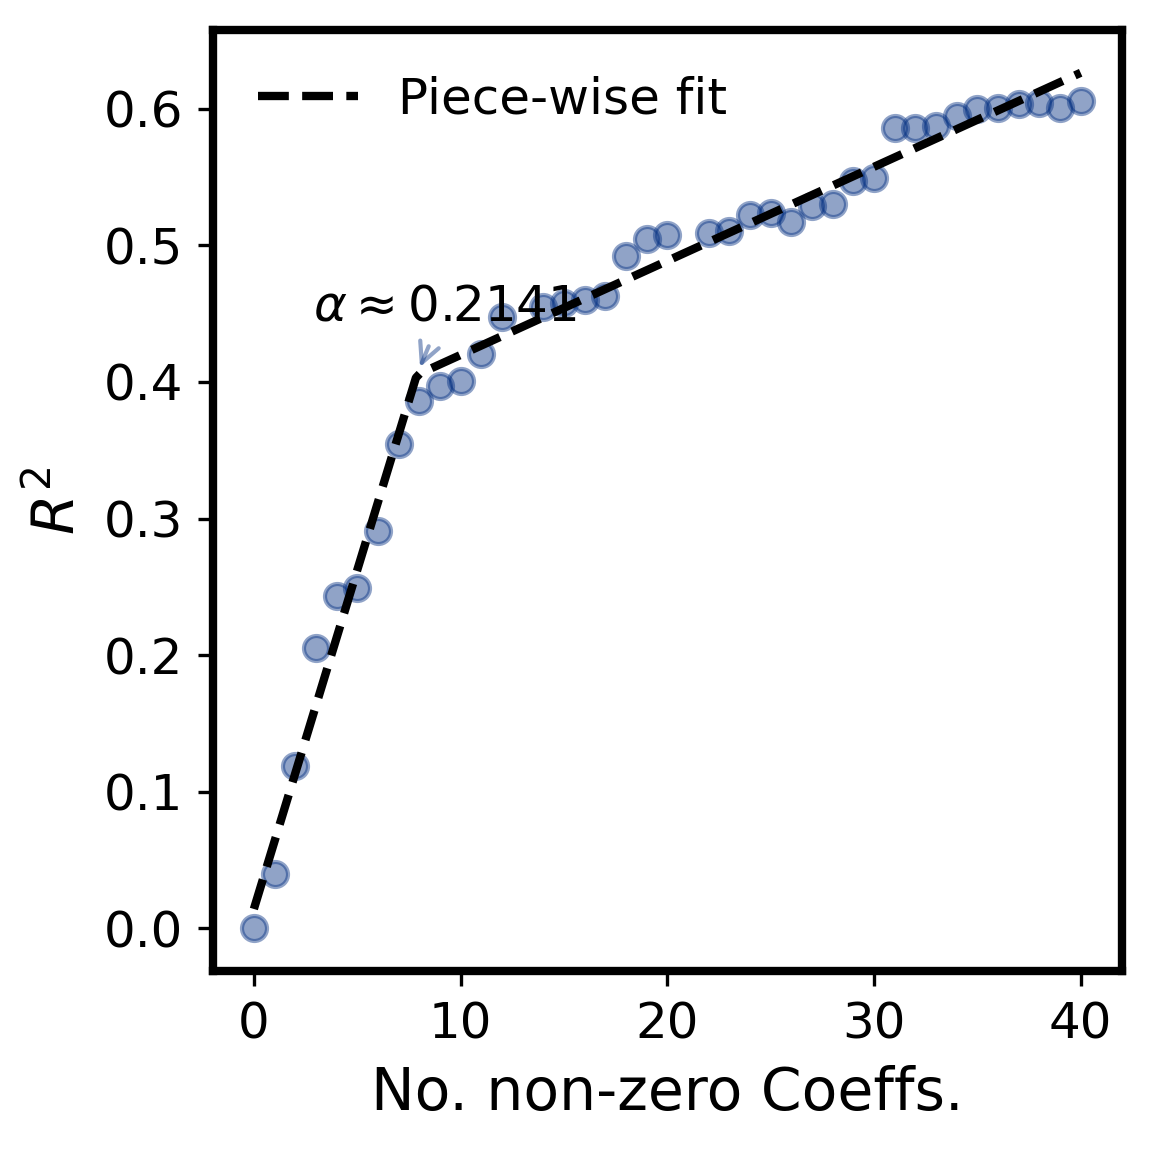

In [14]:
fig, ax = plt.subplots(1, 1, figsize=(4, 4),dpi=300)

nnzidx = []
nnz_unique = []
r2_clean_unique = []

# Only unique nnz values
for i in range(len(alphas)):
    nnz_c = len(models[i].coef_.nonzero()[0])
    if nnz_c not in nnz_unique:
        nnzidx.append(i)
        nnz_unique.append(nnz_c)
        r2_clean_unique.append(r2_scores[i])

nnz_unique = np.asarray(nnz_unique)
r2_clean_unique = np.asarray(r2_clean_unique)

ax.scatter(nnz_unique, r2_clean_unique, color="#002D806F")

# Define piecewise-linear function with x0 as a parameter
def piecewise_linear(x, x0, c, m1, m2):
    return np.where(x < x0, m1 * (x - x0) + c, m2 * (x - x0) + c)

# Initial guess for x0: middle of the range
x0_guess = np.median(nnz_unique)
p0 = [x0_guess, 0.5, 0.01, -0.01]

# Fit the piecewise function
popt, _ = optimize.curve_fit(piecewise_linear, nnz_unique, r2_clean_unique, p0=p0)

x0_fit, c_fit, m1_fit, m2_fit = popt
print(f"Fitted x0: {x0_fit:.2f}")

# Find nearest index to fitted x0
nearest_idx = np.argmin(np.abs(nnz_unique - x0_fit))
fitted_alpha = alphas[nnzidx[nearest_idx]]
print(f"Corresponding alpha ≈ {fitted_alpha:.4f}")

# Plot the fit
x_vals = np.linspace(nnz_unique.min(), nnz_unique.max(), 200)
ax.plot(x_vals, piecewise_linear(x_vals, *popt), "--k", lw=2, label="Piece-wise fit")

# Labels
ax.set_xlabel("No. non-zero Coeffs.", fontsize=14)
ax.set_ylabel(r"$R^2$", fontsize=14)
ax.tick_params(axis="both", labelsize=12)

# Annotate the fitted point
arrow_x = x0_fit
arrow_y = piecewise_linear(x0_fit, *popt)
ax.annotate(
    fr"$\alpha \approx${fitted_alpha:.4f}",
    xy=(arrow_x, arrow_y),
    xytext=(arrow_x - 5, arrow_y + 0.04),
    arrowprops=dict(arrowstyle="->", color="#002D806F"),
    fontsize=12,
    color="black",
)

for side in ax.spines.values():
    side.set_linewidth(2.0)

ax.legend(frameon=False)
plt.tight_layout()
plt.show()

In [15]:
# round x0_fit to find the closest nnz value and model index
x0_rounded = int(round(x0_fit))
# find index in nnz_unique closest to x0_rounded
closest_nnz_idx = np.argmin(np.abs(nnz_unique - x0_rounded))
# get the original index for model selection
model_index = nnzidx[closest_nnz_idx]
clf_dG = models[model_index]

# get nonzero coefficients
nz_coeffs = clf_dG.coef_.nonzero()[0]
print("N params: ", len(nz_coeffs))
for i in nz_coeffs:
    print(f"{df_selected.columns[i]}: {clf_dG.coef_[i]:.4f}")

N params:  8
MinAbsEStateIndex: -4.6684
qed: 2.1195
MolWt: -11.7957
Kappa1: -5.3294
PEOE_VSA11: -0.8512
SlogP_VSA5: 11.7489
EState_VSA5: 1.1557
FractionCSP3: 6.6212


N params:  8


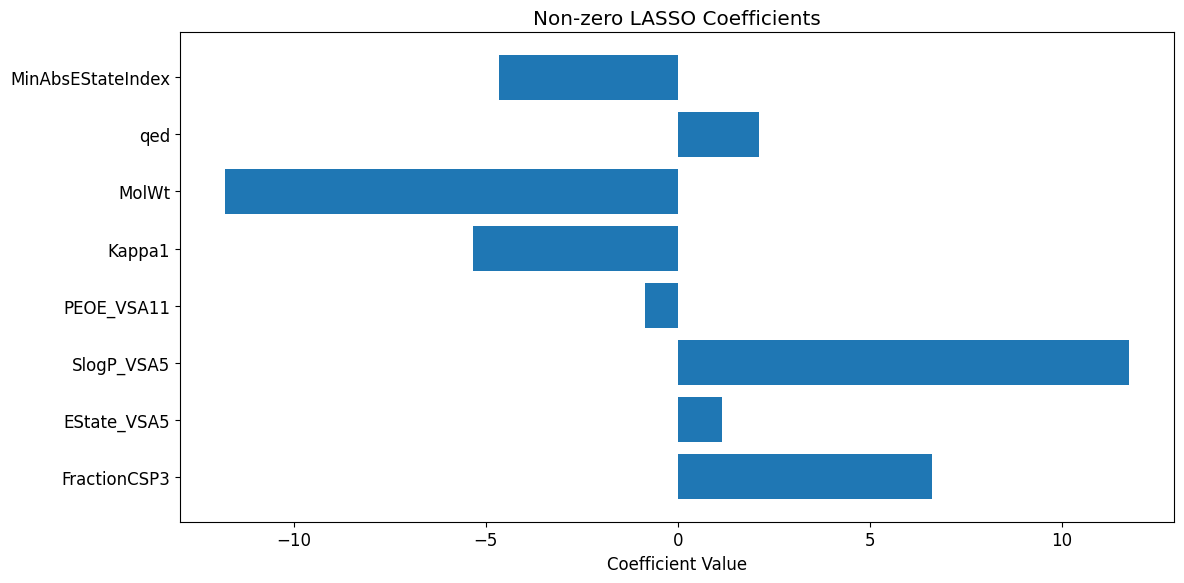

In [16]:
nz_coeffs = clf_dG.coef_.nonzero()[0]
print("N params: ", len(nz_coeffs))

# Get feature names and their corresponding weights
feature_names = [df_selected.columns[i] for i in nz_coeffs]
coefficients = [clf_dG.coef_[i] for i in nz_coeffs]

# Print the features and weights
# for name, val in zip(feature_names, coefficients):
#     print(f"{name}: {val:.4f}")

# Plot


plt.figure(figsize=(12, 6))
plt.barh(feature_names, coefficients)
plt.xlabel("Coefficient Value")
plt.title("Non-zero LASSO Coefficients")
plt.gca().invert_yaxis()  # Most important on top
plt.tight_layout()
plt.show()

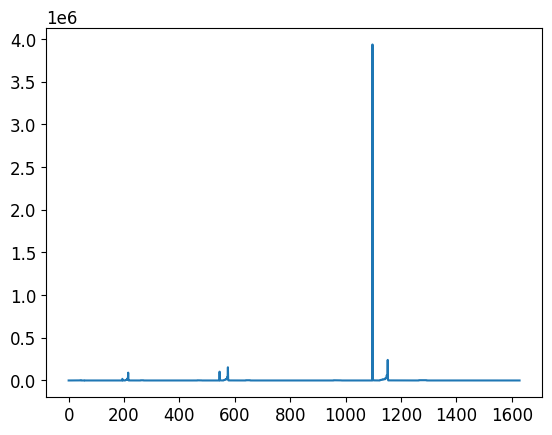

In [17]:
# plot_df
plt.plot(list(df_selected['Kappa1']))

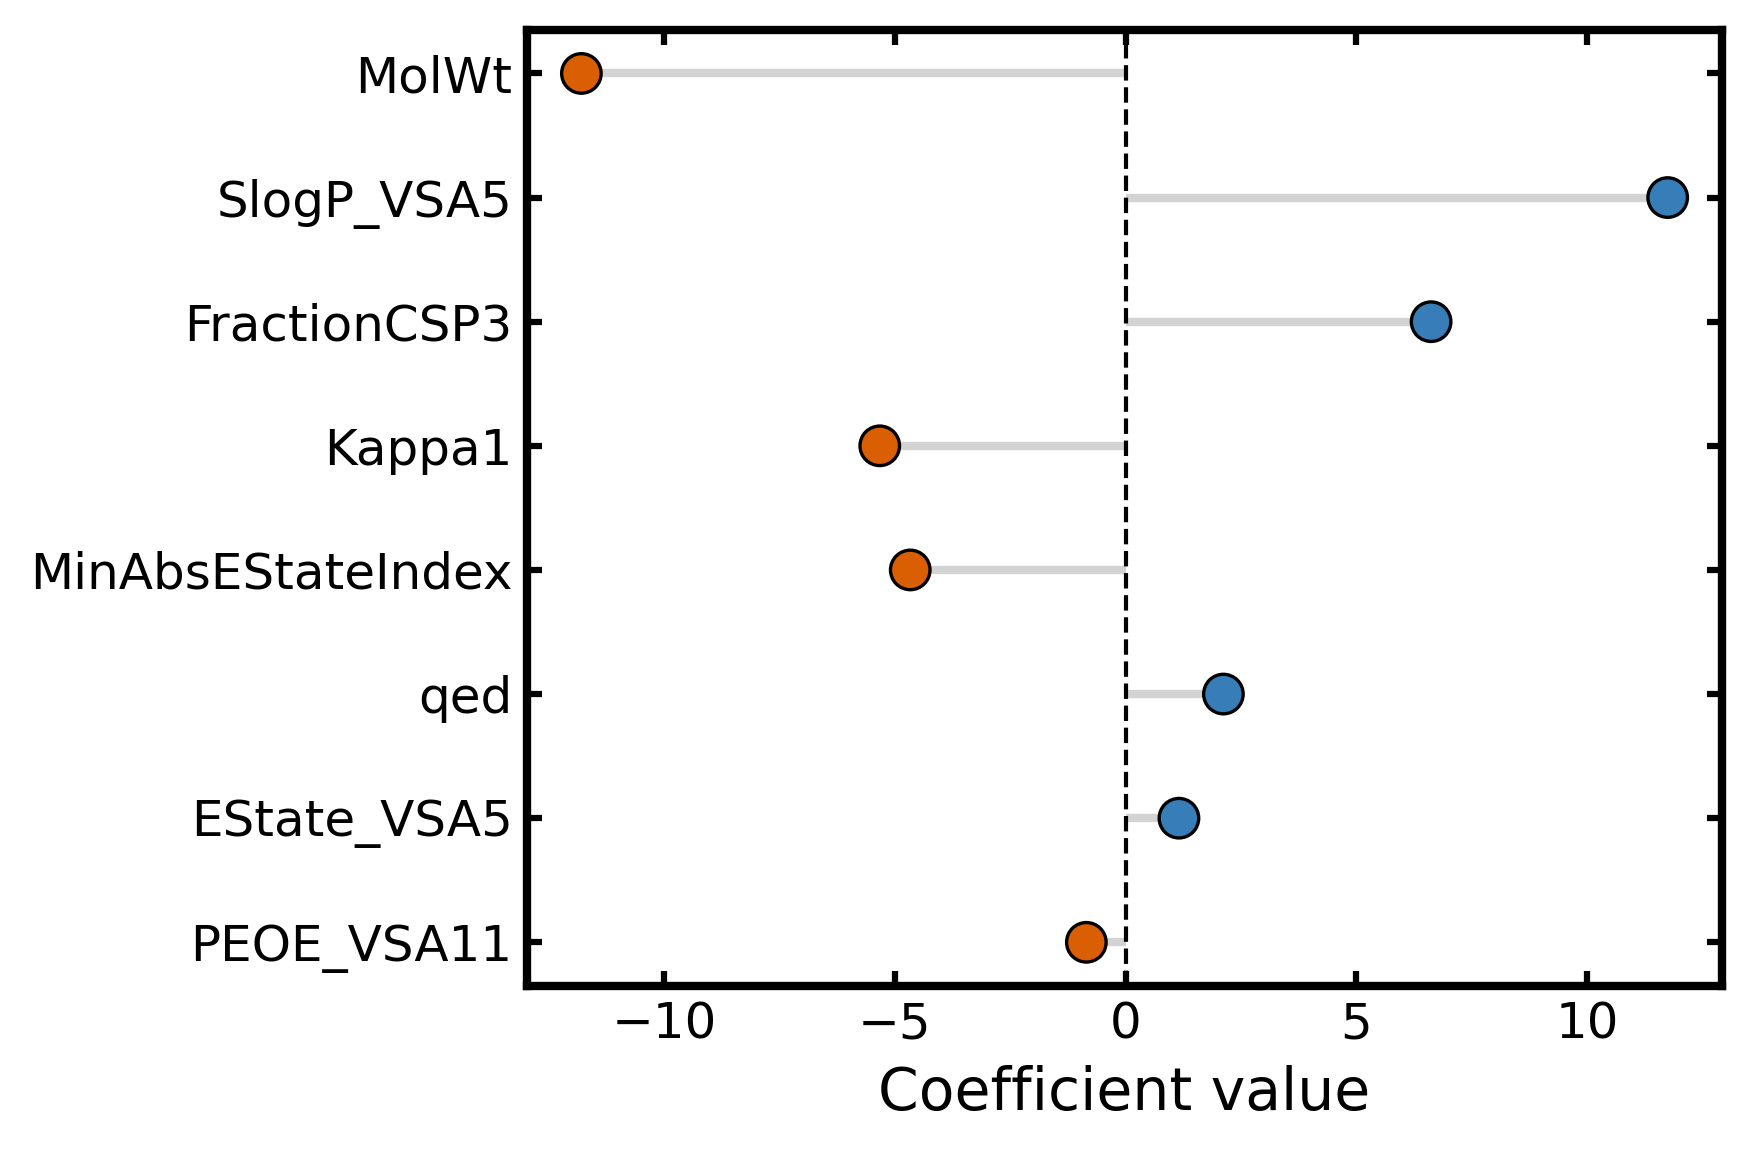

In [18]:
# --- build a small table with standardized effects (Δŷ per +1 SD) ---
feat_df = df_selected[feature_names]                  # same columns used by the model
sd = feat_df.std(ddof=0)                              # population SD to match scikit-learn scaling convention
beta = pd.Series(coefficients, index=feature_names)
beta_std = beta * sd[feature_names]                   # effect size per +1 SD

plot_df = (
    pd.DataFrame({
        'feature': feature_names,
        'beta_std': beta_std.values,
        'beta': beta.values
    })
    .assign(abs_std=lambda d: d['beta'].abs())
    .sort_values('abs_std', ascending=False)           # smallest at bottom, biggest on top after invert_yaxis
)

# --- lollipop plot of standardized effects ---
fig, ax = plt.subplots(figsize=(6, 4),dpi=300)

y = np.arange(len(plot_df))
ax.hlines(y, xmin=0, xmax=plot_df['beta'], color='lightgray', linewidth=2, zorder=1)
colors = np.where(plot_df['beta'] >= 0, '#377eb8', '#d95f02')  # blue for +, orange for -

ax.scatter(plot_df['beta'], y, s=90, color=colors, edgecolors='black', linewidths=0.8, zorder=2)

# zero line
ax.axvline(0, color='k', linestyle='--', linewidth=1)

# labels & ticks
ax.set_yticks(y)
ax.set_yticklabels(plot_df['feature'])
ax.set_xlabel('Coefficient value', fontsize=14)
# ax.set_title('LASSO descriptor contributions (standardized)')

# put the most important on top
ax.invert_yaxis()

# thicker spines & ticks
for spine in ax.spines.values():
    spine.set_linewidth(2.0)
ax.tick_params(direction='in', top=True, right=True, width=1.5)

plt.tight_layout()
plt.show()

In [31]:
# plt.plot(Y_fit_ddG_md)
# plt.plot(Y_fit_dG_md)

/home/siddarthachar/miniconda3/envs/graphdot_env/lib/python3.8/site-packages/sklearn/linear_model/_coordinate_descent.py:628: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 3.239e+02, tolerance: 1.165e+00
  model = cd_fast.enet_coordinate_descent(
/home/siddarthachar/miniconda3/envs/graphdot_env/lib/python3.8/site-packages/sklearn/linear_model/_coordinate_descent.py:628: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 3.251e+02, tolerance: 1.165e+00
  model = cd_fast.enet_coordinate_descent(
/home/siddarthachar/miniconda3/envs/graphdot_env/lib/python3.8/site-packages/sklearn/linear_model/_coordinate_descent.py:628: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, c

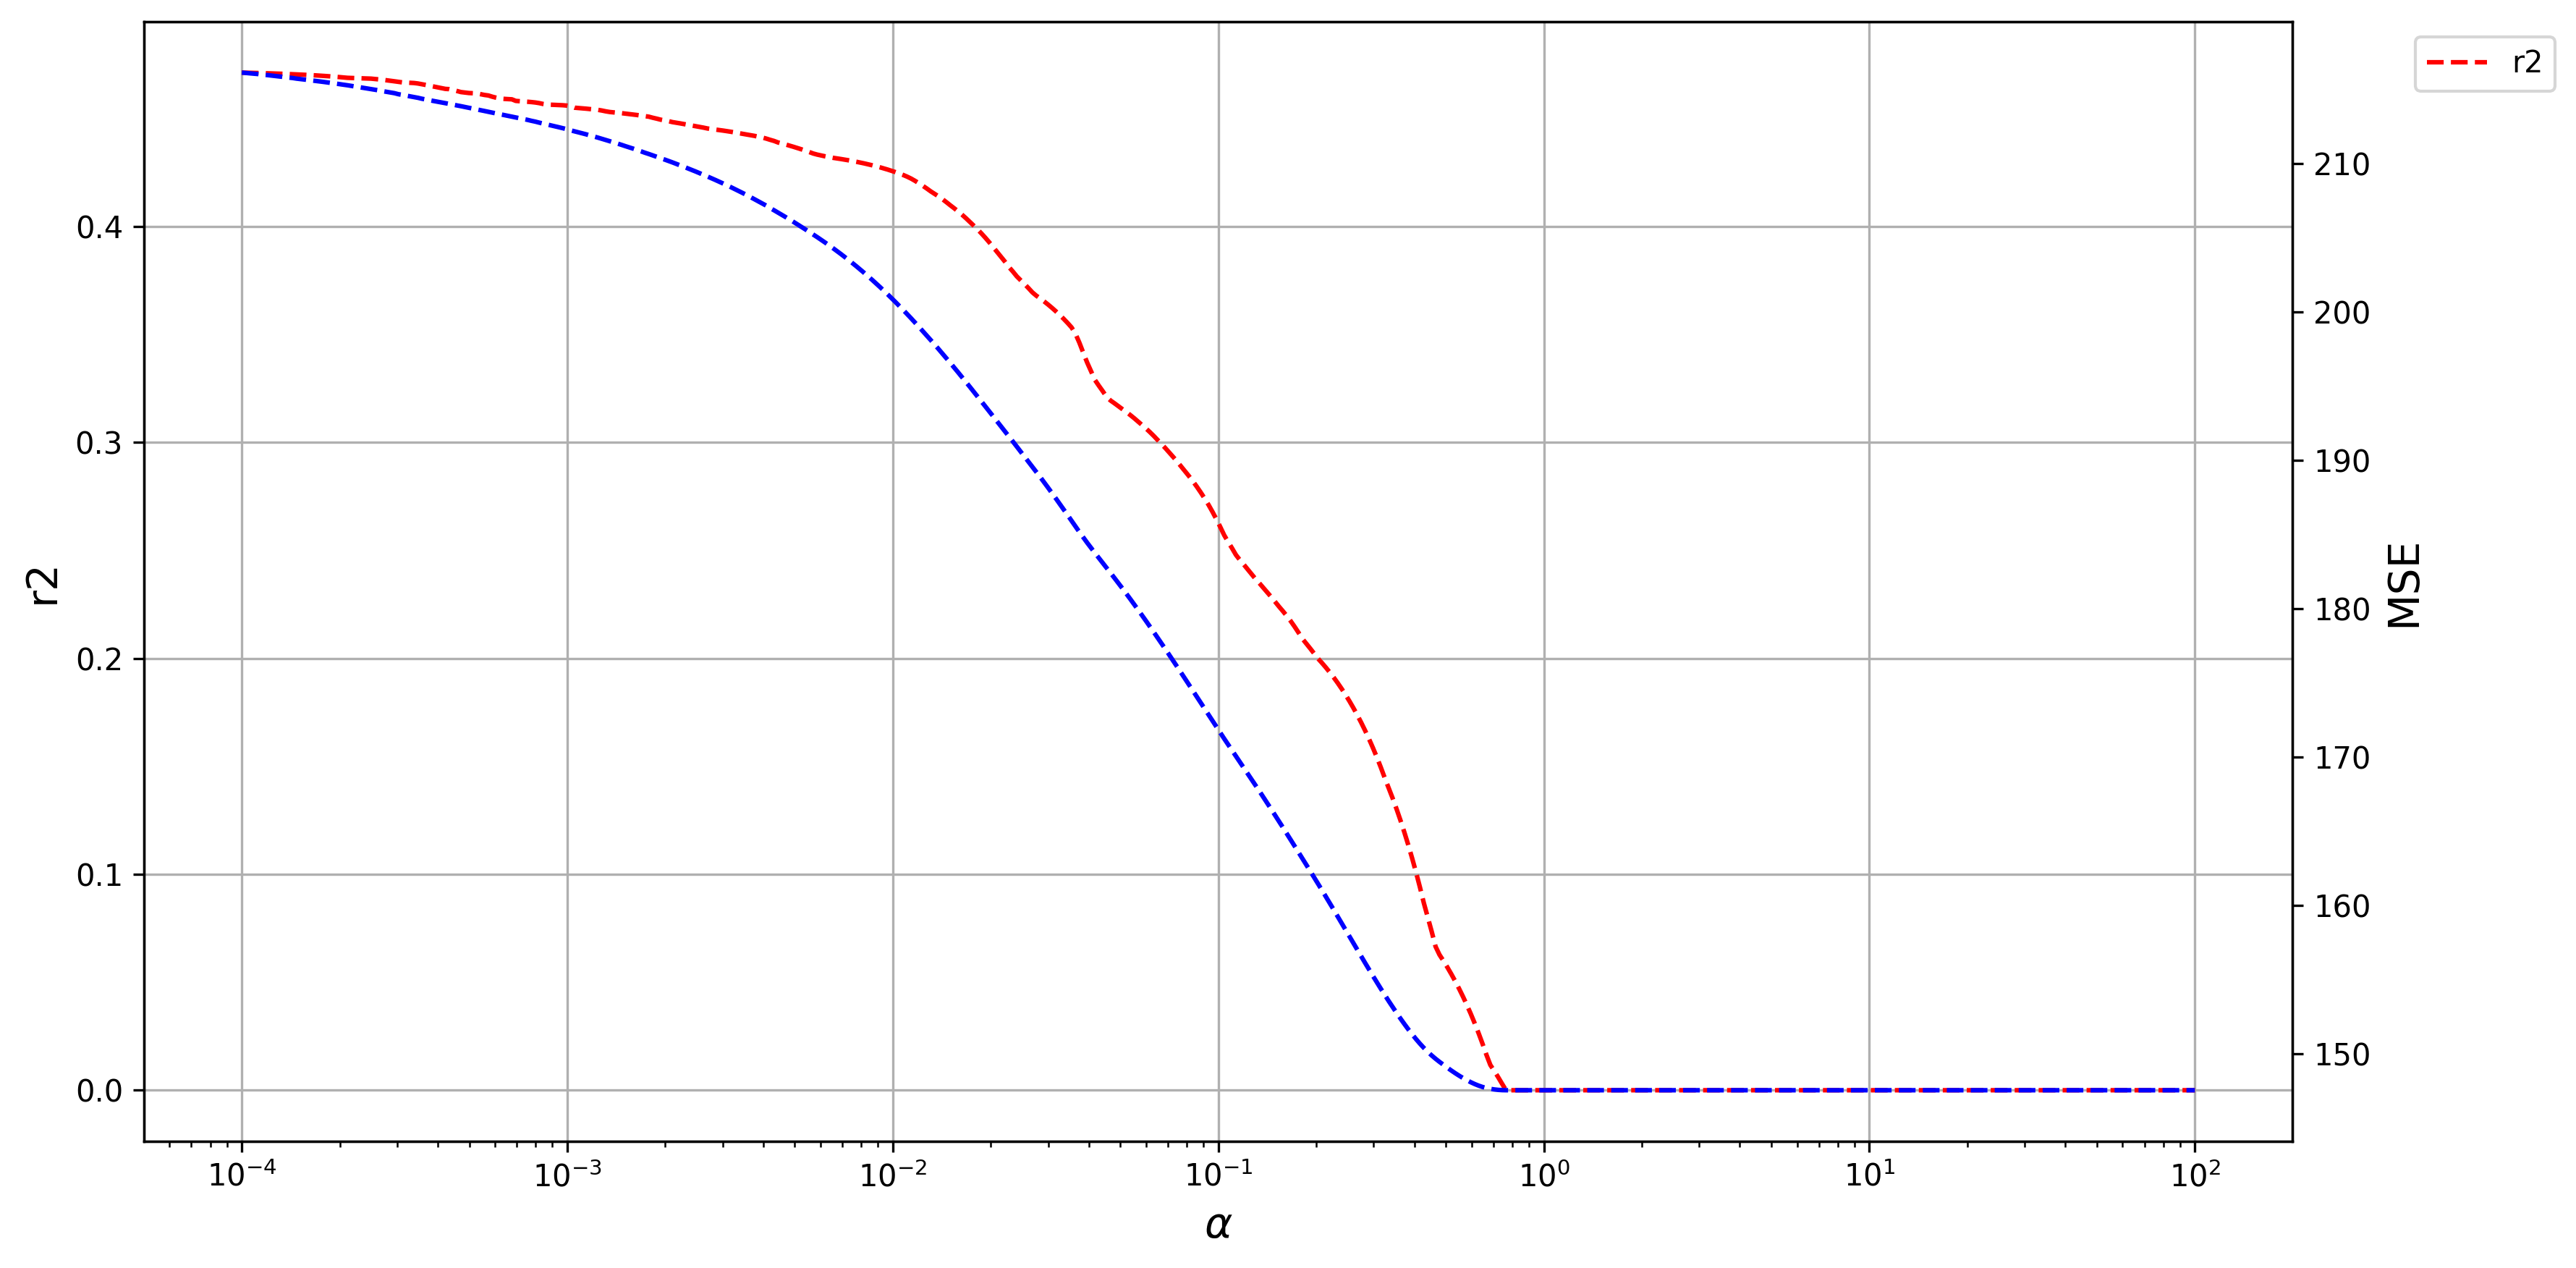

In [19]:
# Define grid of lambda values (alphas in sklearn)
alphas = np.logspace(-4, 2, 500)
n_features = X_fit.shape[1]
y = Y_fit_ddG_md

# Store coefficients for each alpha and each fold
r2_scores = np.zeros((len(alphas), ))
MSE = np.zeros((len(alphas), ))
models = []

scaler_all_vina = MinMaxScaler()
X_train = scaler_all_vina.fit_transform(X_fit)
for j, alpha in enumerate(alphas):
    model = Lasso(alpha=alpha, max_iter=100000)
    model.fit(X_train, y)
    r2_scores[j] = model.score(X_train, y)
    MSE[j] = ((model.predict(X_train)-y)**2).mean()
    models.append(model)

fig, ax = plt.subplots(figsize=(12, 6), dpi=300)
colors = plt.cm.tab20.colors

ax2 = ax.twinx()
ax.plot(alphas, r2_scores, "--r", label="r2")
ax2.plot(alphas, MSE, "--b", label="MSE")
ax.grid()
ax.set_xscale("log")
ax.set_xlabel(r"$\alpha$", fontsize=14)
ax.set_ylabel("r2", fontsize=14)
ax.legend(bbox_to_anchor=(1.05, 1), loc='upper left', fontsize='small', ncol=2)
ax.tick_params(axis="both", which='major', labelsize=10)
ax2.tick_params(axis="both", which='major', labelsize=10)
ax2.set_ylabel("MSE", fontsize=14)
fig.tight_layout()
plt.show()

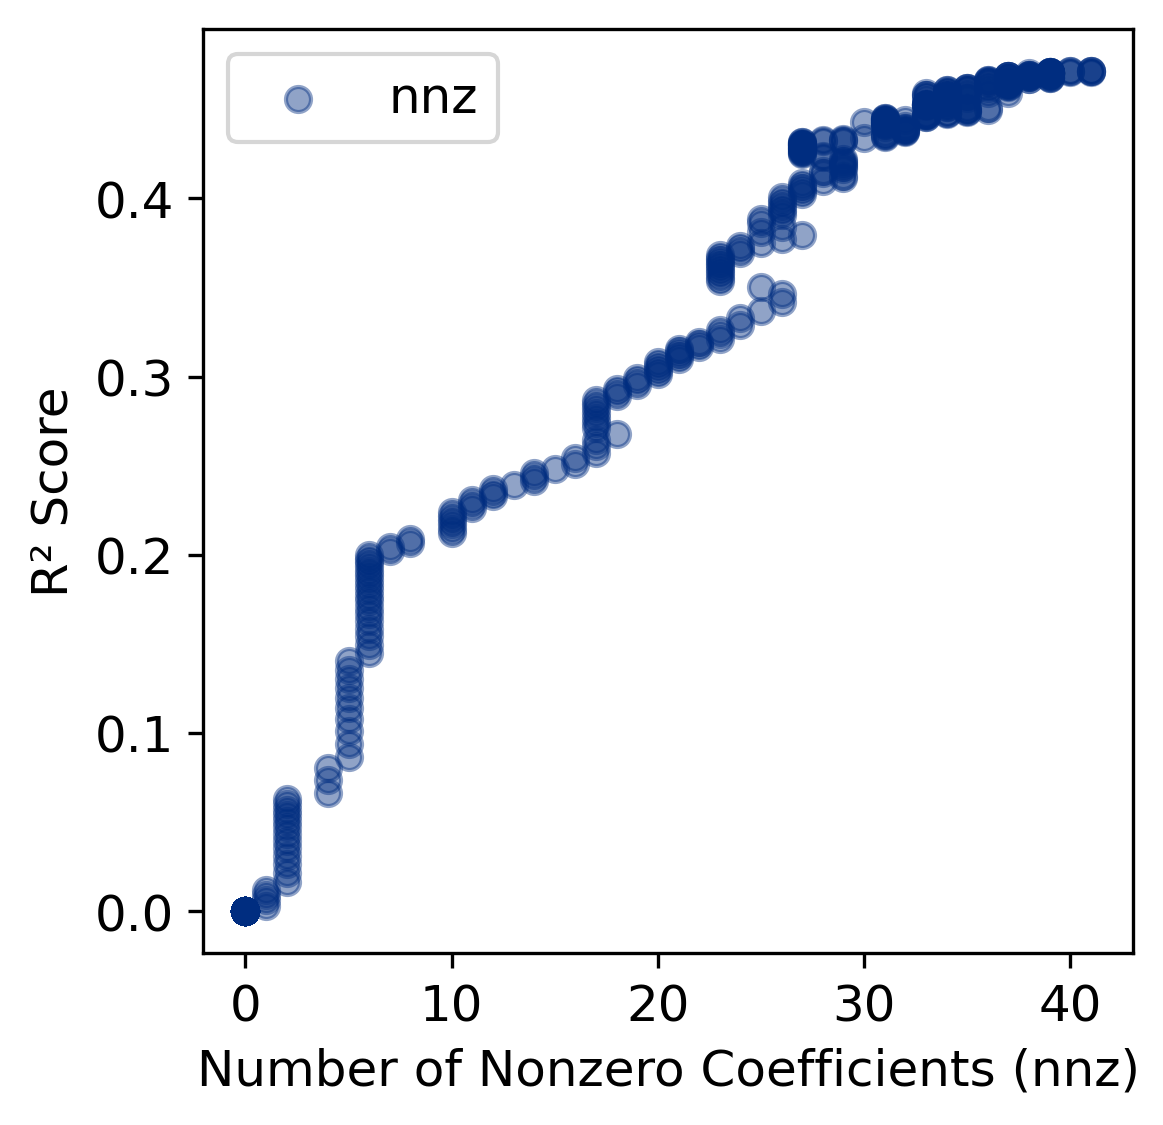

In [20]:
fig, ax = plt.subplots(1, 1, figsize=(4, 4), dpi=300)
# ax.set_xscale("log")

nnz = [len(model.coef_.nonzero()[0]) for model in models]
r2_clean = r2_scores

nnz = np.asarray(nnz)
r2_clean = np.asarray(r2_clean)

ax.scatter(nnz, r2_clean, color="#002D806F", label="nnz")
ax.set_xlabel("Number of Nonzero Coefficients (nnz)")
ax.set_ylabel("R² Score")
ax.legend()
plt.show()

Fitted x0: 28.51
Corresponding alpha ≈ 0.0059


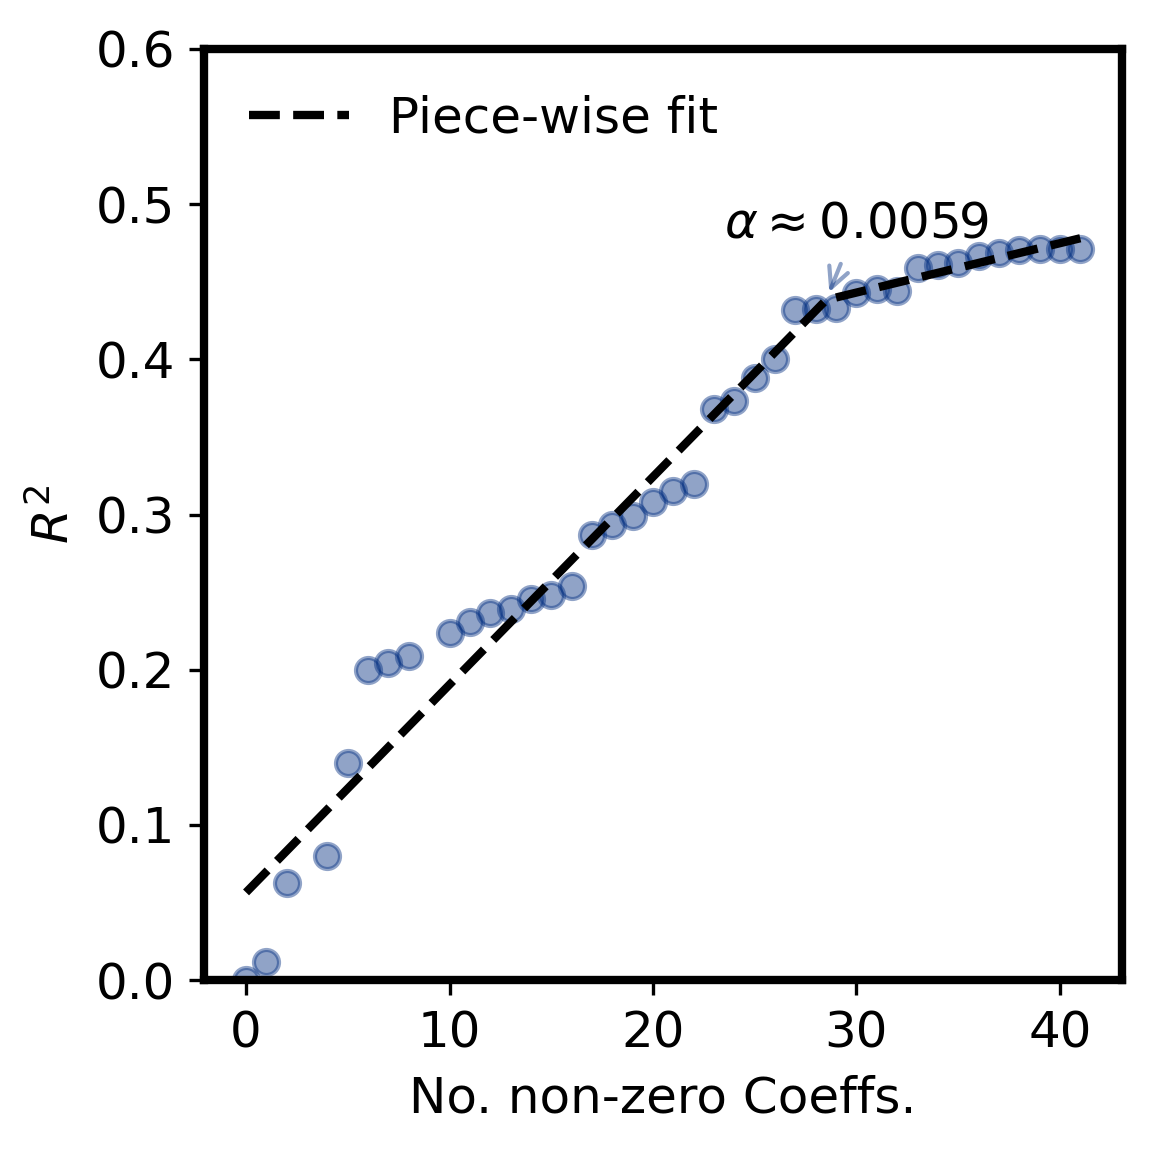

In [21]:
fig, ax = plt.subplots(1, 1, figsize=(4,4), dpi=300)

nnzidx = []
nnz_unique = []
r2_clean_unique = []

# Only unique nnz values
for i in range(len(alphas)):
    nnz_c = len(models[i].coef_.nonzero()[0])
    if nnz_c not in nnz_unique:
        nnzidx.append(i)
        nnz_unique.append(nnz_c)
        r2_clean_unique.append(r2_scores[i])

nnz_unique = np.asarray(nnz_unique)
r2_clean_unique = np.asarray(r2_clean_unique)

ax.scatter(nnz_unique, r2_clean_unique, color="#002D806F")

# Define piecewise-linear function with x0 as a parameter
def piecewise_linear(x, x0, c, m1, m2):
    return np.where(x < x0, m1 * (x - x0) + c, m2 * (x - x0) + c)

# Initial guess for x0: middle of the range
x0_guess = np.median(nnz_unique)
p0 = [x0_guess, 0.5, 0.01, -0.01]

# Fit the piecewise function
popt, _ = optimize.curve_fit(piecewise_linear, nnz_unique, r2_clean_unique, p0=p0)

x0_fit, c_fit, m1_fit, m2_fit = popt
print(f"Fitted x0: {x0_fit:.2f}")

# Find nearest index to fitted x0
nearest_idx = np.argmin(np.abs(nnz_unique - x0_fit))
fitted_alpha = alphas[nnzidx[nearest_idx]]
print(f"Corresponding alpha ≈ {fitted_alpha:.4f}")

# Plot the fit
x_vals = np.linspace(nnz_unique.min(), nnz_unique.max(), 200)
ax.plot(x_vals, piecewise_linear(x_vals, *popt), "--k", lw=2, label="Piece-wise fit")

# Labels
ax.set_xlabel("No. non-zero Coeffs.")
ax.set_ylabel(r"$R^2$")
ax.set_ylim(0, 0.6)
ax.tick_params(axis="both")

# Annotate the fitted point
arrow_x = x0_fit
arrow_y = piecewise_linear(x0_fit, *popt)
ax.annotate(
    fr"$\alpha \approx${fitted_alpha:.4f}",
    xy=(arrow_x, arrow_y),
    xytext=(arrow_x - 5, arrow_y + 0.04),
    arrowprops=dict(arrowstyle="->", color="#002D806F"),
    fontsize=12,
    color="black",
)

for side in ax.spines.values():
    side.set_linewidth(2.0)

ax.legend(frameon=False, loc='upper left')
plt.tight_layout()
plt.show()

In [22]:
# round x0_fit to find the closest nnz value and model index
x0_rounded = int(round(x0_fit))
# find index in nnz_unique closest to x0_rounded
closest_nnz_idx = np.argmin(np.abs(nnz_unique - x0_rounded))
# get the original index for model selection
model_index = nnzidx[closest_nnz_idx]
clf_dG = models[model_index]

# get nonzero coefficients
nz_coeffs = clf_dG.coef_.nonzero()[0]
print("N params: ", len(nz_coeffs))
for i in nz_coeffs:
    print(f"{df_selected.columns[i]}: {clf_dG.coef_[i]:.4f}")

nz_coeffs = clf_dG.coef_.nonzero()[0]
print("N params: ", len(nz_coeffs))

# Get feature names and their corresponding weights
feature_names = [df_selected.columns[i] for i in nz_coeffs]
coefficients = [clf_dG.coef_[i] for i in nz_coeffs]

N params:  29
MaxAbsEStateIndex: 15.1947
MinAbsEStateIndex: -26.6477
MinEStateIndex: 40.3129
qed: 25.5069
MinPartialCharge: 18.7581
FpDensityMorgan1: -9.4959
BCUT2D_MWLOW: 7.7070
Chi4n: -36.7080
Kappa1: -5.4620
Kappa3: -1.1281
PEOE_VSA10: 66.2532
PEOE_VSA11: 17.0727
PEOE_VSA12: 14.8911
PEOE_VSA14: 19.7521
PEOE_VSA2: 42.7614
PEOE_VSA3: -12.3089
PEOE_VSA7: 11.6871
PEOE_VSA8: 6.7484
PEOE_VSA9: -43.6510
SMR_VSA3: -0.2712
SlogP_VSA10: 80.9169
SlogP_VSA5: 15.1764
EState_VSA5: 2.6067
EState_VSA8: -3.7754
VSA_EState5: 7.4943
VSA_EState6: -0.8860
VSA_EState7: 0.7305
FractionCSP3: 8.4865
CD type: 3.9222
N params:  29


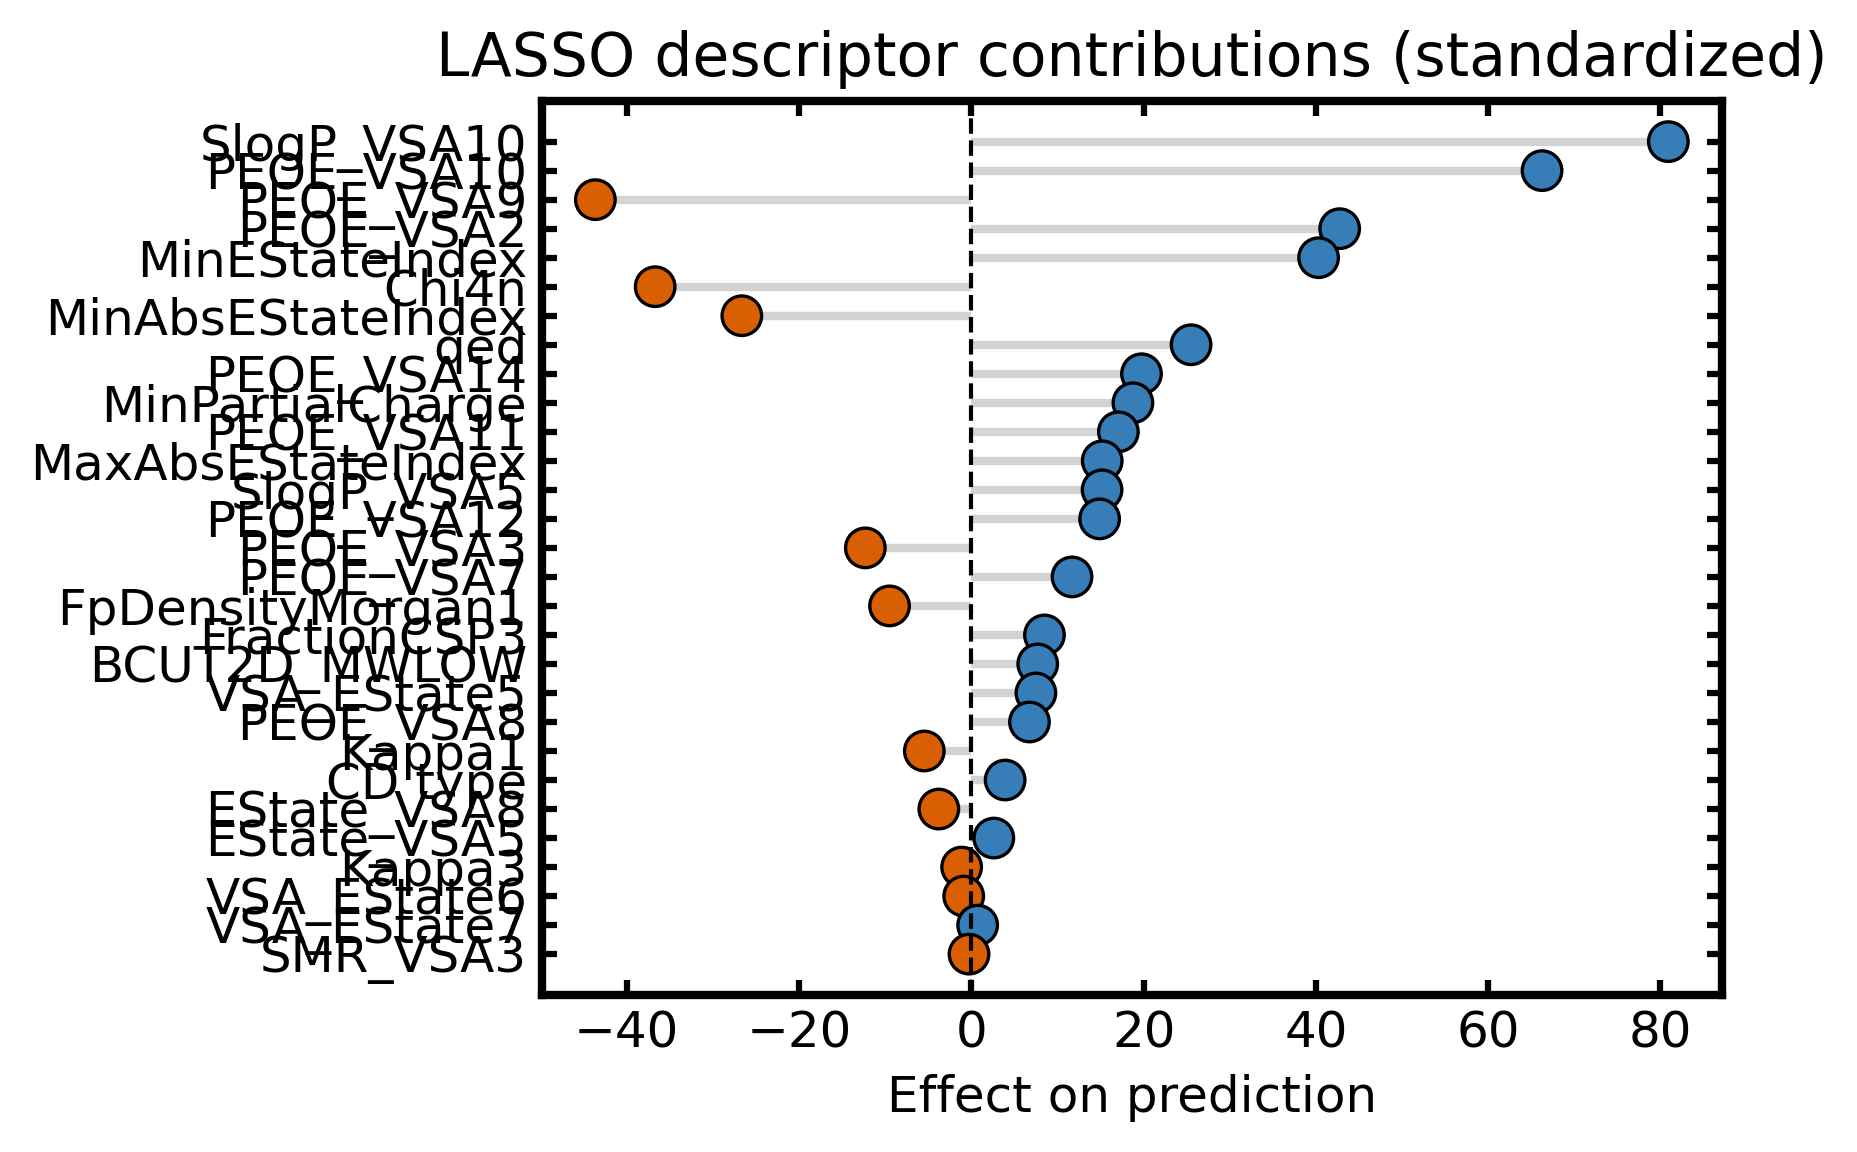

In [23]:
# --- build a small table with standardized effects (Δŷ per +1 SD) ---
feat_df = df_selected[feature_names]                  # same columns used by the model
sd = feat_df.std(ddof=0)                              # population SD to match scikit-learn scaling convention
beta = pd.Series(coefficients, index=feature_names)
beta_std = beta * sd[feature_names]                   # effect size per +1 SD

plot_df = (
    pd.DataFrame({
        'feature': feature_names,
        'beta_std': beta_std.values,
        'beta': beta.values
    })
    .assign(abs_std=lambda d: d['beta'].abs())
    .sort_values('abs_std', ascending=False)           # smallest at bottom, biggest on top after invert_yaxis
)

# --- lollipop plot of standardized effects ---
fig, ax = plt.subplots(figsize=(6, 4),dpi=300)

y = np.arange(len(plot_df))
ax.hlines(y, xmin=0, xmax=plot_df['beta'], color='lightgray', linewidth=2, zorder=1)
colors = np.where(plot_df['beta'] >= 0, '#377eb8', '#d95f02')  # blue for +, orange for -

ax.scatter(plot_df['beta'], y, s=90, color=colors, edgecolors='black', linewidths=0.8, zorder=2)

# zero line
ax.axvline(0, color='k', linestyle='--', linewidth=1)

# labels & ticks
ax.set_yticks(y)
ax.set_yticklabels(plot_df['feature'])
ax.set_xlabel('Effect on prediction')
ax.set_title('LASSO descriptor contributions (standardized)')

# put the most important on top
ax.invert_yaxis()

# thicker spines & ticks
for spine in ax.spines.values():
    spine.set_linewidth(2.0)
ax.tick_params(direction='in', top=True, right=True, width=1.5)

plt.tight_layout()
plt.show()

In [25]:
plot_df[:10]

,feature,beta_std,beta,abs_std
20,SlogP_VSA10,2704.198178,80.916903,80.916903
10,PEOE_VSA10,852.624133,66.253213,66.253213
18,PEOE_VSA9,-268.166205,-43.650981,43.650981
14,PEOE_VSA2,430.446018,42.761423,42.761423
2,MinEStateIndex,75.366825,40.312940,40.312940
7,Chi4n,-8.389620,-36.708021,36.708021
1,MinAbsEStateIndex,-11.791444,-26.647697,26.647697
3,qed,3.242178,25.506912,25.506912
13,PEOE_VSA14,388.034283,19.752087,19.752087
4,MinPartialCharge,1.177375,18.758139,18.758139
